In [21]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)


Setup complete. NumPy 2.1.3


1. Probability theory & axioms

1A. PROBABILITY BY SIMULATION

In [22]:
rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


1B. THE ADDITION RULE (disjoint events)

In [23]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


 LAB EXERCISE 1 — Probability by simulation

In [24]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)


In [25]:
# 1. P(both heads)  -> heads == 2
p_both_heads = (heads == 2).mean()
print('P(both heads) ~', round(p_both_heads, 3))


P(both heads) ~ 0.252


In [26]:
# 2. P(at least one head)  -> heads >= 1
p_at_least_one = (heads >= 1).mean()
print('P(at least one head) ~', round(p_at_least_one, 3))


P(at least one head) ~ 0.749


In [27]:
# 3. Do P(0) + P(1) + P(2) sum to 1?
p_0 = (heads == 0).mean()
p_1 = (heads == 1).mean()
p_2 = (heads == 2).mean()

print('P(0) + P(1) + P(2) =', round(p_0 + p_1 + p_2, 3))


P(0) + P(1) + P(2) = 1.0


2. Conditional probability & independence

In [28]:
#2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)


rolls = np.random.randint(1, 7, size=100_000)


even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')


P(6 | even) ~ 0.332  (true 1/3)


In [29]:
#2B. TESTING FOR INDEPENDENCE


A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))


P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


 LAB EXERCISE 2 — Conditional probability

In [30]:
# 1. P(odd | roll < 4)
less_than_4 = rolls[rolls < 4]
p_odd_given_less4 = (less_than_4 % 2 == 1).mean()
print('P(odd | roll < 4) ~', round(p_odd_given_less4, 3))


P(odd | roll < 4) ~ 0.668


In [31]:
# 2. P(roll < 4)
p_less4 = (rolls < 4).mean()
print('P(roll < 4) ~', round(p_less4, 3))


P(roll < 4) ~ 0.502


In [32]:
# 3. Compare P(odd | <4) with P(odd) overall — independent?
p_odd = (rolls % 2 == 1).mean()

print('P(odd | roll < 4) =', round(p_odd_given_less4, 3))
print('P(odd)            =', round(p_odd, 3))
print('Independent?', np.isclose(p_odd_given_less4, p_odd, atol=0.02))


P(odd | roll < 4) = 0.668
P(odd)            = 0.502
Independent? False


3. Bayes' theorem

3A. THE MEDICAL-TEST PROBLEM (by formula)

In [33]:

p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01


p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)


p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')


P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


3B. THE SAME ANSWER BY SIMULATION (sanity check)

In [34]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease

tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))


Simulated P(sick | positive) = 0.498


LAB EXERCISE 3 — A Bayes scenario (spam filter)

In [35]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05


In [36]:
# 2. P('free') via total probability
p_free = p_free_given_spam * p_spam + p_free_given_ham * (1 - p_spam)
print('P(free) =', round(p_free, 3))


P(free) = 0.16


In [37]:
# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print('P(spam | free) =', round(p_spam_given_free, 3))


P(spam | free) = 0.75


4. Probability distributions

 4A. BERNOULLI & POISSON (discrete)

In [38]:
# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')



Bernoulli(0.3) mean ~ 0.293 (true 0.3)


In [39]:
# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')


Poisson(4) mean ~ 4.006 (true 4)


 4B. THE GAUSSIAN (normal) — plot the bell curve

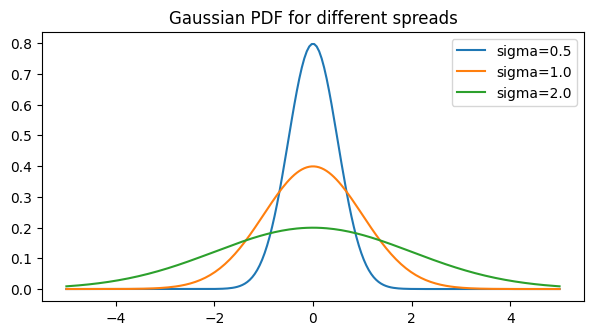

In [40]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()


LAB EXERCISE 4 — Simulate & plot distributions

In [41]:
# 1. Poisson(mu=2) samples + mean
pois = stats.poisson(mu=2).rvs(size=10_000)
print('Sample mean:', round(pois.mean(), 3))


Sample mean: 2.019


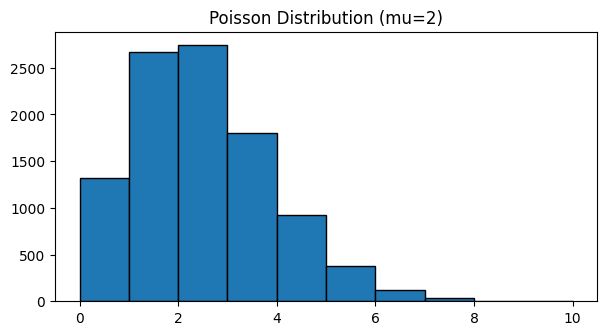

In [42]:
# 2. histogram of the samples
plt.figure(figsize=(7, 3.5))
plt.hist(pois, bins=range(pois.max() + 2), edgecolor='black')
plt.title('Poisson Distribution (mu=2)')
plt.show()


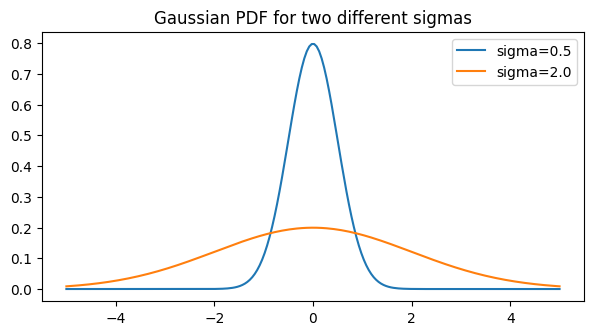

In [43]:
# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-5, 5, 200)

plt.figure(figsize=(7, 3.5))
plt.plot(x, stats.norm(0, 0.5).pdf(x), label='sigma=0.5')
plt.plot(x, stats.norm(0, 2.0).pdf(x), label='sigma=2.0')
plt.title('Gaussian PDF for two different sigmas')
plt.legend()
plt.show()


5. Entropy, KL divergence & mutual information

5A. ENTROPY — how uncertain is a distribution?

In [44]:
from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]


print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')


Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


 5B. KL DIVERGENCE — how far is Q from P?

In [45]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])


print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


5C. MUTUAL INFORMATION — which feature is most informative?

In [46]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


LAB EXERCISE 5 — Information theory

In [ ]:
# 1. Entropy of a fair 4-sided and 6-sided die
fair_4 = [1/4] * 4
fair_6 = [1/6] * 6

print('Entropy 4-sided die:', round(entropy(fair_4, base=2), 3), 'bits')
print('Entropy 6-sided die:', round(entropy(fair_6, base=2), 3), 'bits')


In [ ]:
# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')


In [ ]:
# 3. Most / least informative iris feature
iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)

most_idx = np.argmax(mi)
least_idx = np.argmin(mi)

print('Most informative:', iris.feature_names[most_idx])
print('Least informative:', iris.feature_names[least_idx])
